# CogniCrypt — RQ3 effect estimation and assessment

This restart-executable notebook retains the legacy developer-only versus developer-plus-third-party reporting-policy treatment and applies the current RQ1 graph assumptions. Association values are kept in the RQ1 result tables and are not printed on the graph.

In [1]:
from pathlib import Path
import sys
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'causal_analysis').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'causal_analysis').is_dir():
    raise RuntimeError('Run this notebook from the ci4security repository')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from causal_analysis.shared.rq3_analysis import run_rq3_analysis

/Users/mkhan04/Desktop/projects/CauSec/ci4security/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


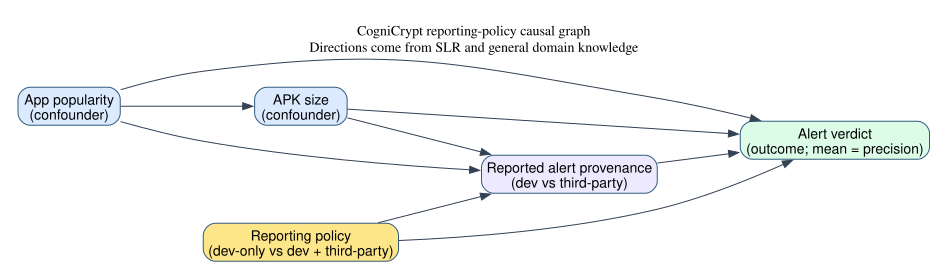

In [2]:
TOOL_NAME = 'CogniCrypt'
TOOL_SLUG = 'cognicrypt'
DATA_PATH = REPO_ROOT / 'causal_analysis/data/cognicrypt/alerts_with_lib_category_and_apk_size_cognicrypt.csv'
GRAPH_PATH = REPO_ROOT / 'causal_analysis/rq1_graph_assessment/graphs/cognicrypt_causal_graph.svg'
OUTPUT_DIR = REPO_ROOT / 'causal_analysis/rq3_effect_estimation/results/cognicrypt'
BOOTSTRAP_SIMULATIONS = 1000
REFUTER_SIMULATIONS = 200
RANDOM_SEED = 20260916
display(SVG(filename=str(GRAPH_PATH)))

## Run the complete workflow

The workflow evaluates overlap and covariate balance; estimates the alert-row ATE risk difference with PSM, standardized logistic regression, and doubly robust AIPW; compares alert-row and popularity-stratified APK-cluster bootstraps; and runs the four legacy refuters plus an unobserved-common-cause sensitivity scenario.

In [3]:
analysis = run_rq3_analysis(
    tool_name=TOOL_NAME,
    source_path=DATA_PATH,
    graph_path=GRAPH_PATH,
    output_dir=OUTPUT_DIR,
    bootstrap_simulations=BOOTSTRAP_SIMULATIONS,
    refuter_simulations=REFUTER_SIMULATIONS,
    seed=RANDOM_SEED,
)
print(f'Results written to {OUTPUT_DIR}')

Results written to /Users/mkhan04/Desktop/projects/CauSec/ci4security/causal_analysis/rq3_effect_estimation/results/cognicrypt


In [4]:
display(analysis['overlap'])
display(analysis['balance'])
display(analysis['matching'])
display(analysis['estimator_results'])
display(analysis['refuters'])
display(analysis['software_validation'])

,reporting_policy,reporting_scope,n_rows,ps_min,ps_q01,ps_q05,ps_q25,ps_median,ps_q75,ps_q95,ps_q99,ps_max,common_support_lower,common_support_upper,n_outside_common_support,percent_outside_common_support,n_extreme_ps_below_0_1_or_above_0_9
0,0,developer_only,498,0.893059,0.895568,0.895568,0.904344,0.916372,0.925439,0.952065,0.954156,0.956158,0.893059,0.956158,0,0.000000,433
1,1,developer_plus_third_party,5675,0.892093,0.893880,0.897708,0.907372,0.919270,0.928917,0.953933,0.961897,0.971544,0.893059,0.956158,144,2.537445,5034


,covariate,smd_before,abs_smd_before,smd_after_psm,abs_smd_after_psm,balanced_after_psm_at_0_1,smd_after_aipw_weighting,abs_smd_after_aipw_weighting,balanced_after_aipw_weighting_at_0_1
0,app_popularity_encoded,0.177817,0.177817,-0.054654,0.054654,True,0.009683,0.009683,True
1,apk_size_scaled,0.171868,0.171868,0.078111,0.078111,True,-0.002766,0.002766,True


,n_treated_rows,n_control_rows,common_support_lower,common_support_upper,n_rows_outside_common_support,percent_rows_outside_common_support,matching_with_replacement,unmatched_rows,unique_controls_used_for_att,unique_treated_used_for_atc,...,mean_atc_propensity_distance,max_atc_propensity_distance,diagnostic_logit_caliper_0_2_sd,att_pairs_above_diagnostic_caliper,atc_pairs_above_diagnostic_caliper,treated_effective_sample_size,control_effective_sample_size,aipw_treated_effective_sample_size,aipw_control_effective_sample_size,n_propensity_scores_clipped_at_0_01_or_0_99
0,5675,498,0.893059,0.956158,144,2.332739,True,0,94,90,...,0.0,0.0,0.04711,195,0,3064.409248,70.457587,5673.381771,475.412404,0


,estimator,estimator_label,effect_scale,target_units,estimate,row_bootstrap_successes,row_bootstrap_se,row_ci_low,row_ci_high,row_ci_width,row_ci_excludes_zero,cluster_bootstrap_successes,cluster_bootstrap_se,cluster_ci_low,cluster_ci_high,cluster_ci_width,cluster_ci_excludes_zero
0,psm,Propensity-score matching,risk_difference,ate,-0.310060,1000,0.044470,-0.348145,-0.170573,0.177572,True,1000,0.054718,-0.394043,-0.179768,0.214274,True
1,logistic_regression,Logistic-regression adjustment,risk_difference,ate,-0.222730,1000,0.019720,-0.262729,-0.185430,0.077299,True,1000,0.038138,-0.302403,-0.151465,0.150938,True
2,doubly_robust,Doubly robust (AIPW),risk_difference,ate,-0.238284,1000,0.019247,-0.275951,-0.201012,0.074939,True,1000,0.032688,-0.311258,-0.180217,0.131041,True


,estimator,refuter,result_index,original_effect,refuter_reference_effect,new_effect,absolute_change_from_original,relative_change_from_original,sign_changed_from_original,p_value,refuter_reports_significant_change,status,error
0,psm,random_common_cause,0,-0.310060,-0.310060,-0.310060,5.551115e-17,1.790336e-16,False,1.00,False,success,None
1,psm,placebo_treatment_refuter,0,-0.310060,-0.310060,-0.001045,3.090151e-01,9.966301e-01,False,0.93,False,success,None
2,psm,data_subset_refuter,0,-0.310060,-0.310060,-0.256860,5.319987e-02,1.715793e-01,False,0.14,False,success,None
3,psm,dummy_outcome_refuter,0,-0.310060,0.000000,-0.013416,2.966444e-01,9.567325e-01,False,0.91,False,success,None
4,psm,add_unobserved_common_cause,0,-0.310060,-0.310060,-0.122469,1.875911e-01,6.050157e-01,False,NaN,None,success,None
5,logistic_regression,random_common_cause,0,-0.222730,-0.222730,-0.222740,9.711314e-06,4.360119e-05,False,0.94,False,success,None
6,logistic_regression,placebo_treatment_refuter,0,-0.222730,-0.222730,-0.000100,2.226310e-01,9.995532e-01,False,0.93,False,success,None
7,logistic_regression,data_subset_refuter,0,-0.222730,-0.222730,-0.222300,4.306667e-04,1.933578e-03,False,0.99,False,success,None
8,logistic_regression,dummy_outcome_refuter,0,-0.222730,0.000000,-0.002573,2.201570e-01,9.884460e-01,False,0.92,False,success,None
9,logistic_regression,add_unobserved_common_cause,0,-0.222730,-0.222730,-0.152568,7.016280e-02,3.150122e-01,False,NaN,None,success,None


,estimator,dowhy_estimate,independent_implementation_estimate,difference,agrees_within_1e_8
0,psm,-0.310060,-0.310060,0.000000e+00,True
1,logistic_regression,-0.222730,-0.222730,2.775558e-17,True
2,doubly_robust,-0.238284,-0.238284,-2.775558e-17,True
